# [04. Residual analysis — model with target treatment that gives the best LOS prediction]

MAE/RMSE tell you *how big* the errors are; residuals tell you *where and why*. We look for **structure and bias**, not magnitude (the model is near-perfect, so residuals are small). Specifically this tests three things flagged earlier:

1. **Overall bias** — is `mean(actual - predicted)` ≈ 0, or systematically off? (For a `log1p` model, watch for the expected slight negative bias from the `expm1` back-transform — Jensen's inequality.)
2. **The LOS-17 ceiling** — do residuals go systematically **positive** for long stays (the known limitation)? Sign convention: `residual = actual - predicted`, so under-prediction (predicting too low, which is what a ceiling forces) yields a **positive** residual.
3. **Heteroscedasticity / patterns** — does error grow with the prediction?

Loads the registered best model from MLflow; rebuilds the test set via `load_and_prepare` (same transform as training).

## 0 · Setup — load best model + rebuild test set

Tries the MLflow registry first; falls back to training a quick baseline if nothing is registered yet. Reads the model's `log_target` from its run so predictions are correctly back-transformed to days.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.lightgbm
from mlflow import MlflowClient

from los_pred.train import load_and_prepare, REGISTERED_MODEL, TRACKING_URI

mlflow.set_tracking_uri(TRACKING_URI)
X_train, y_train, X_test, y_test = load_and_prepare()

log_target = False

#try:
client = MlflowClient()
versions = client.search_model_versions(f"name='{REGISTERED_MODEL}'")
latest = max(versions, key=lambda v: int(v.version))
run = client.get_run(latest.run_id)
log_target = run.data.params.get("log_target", "False") == "True"
model = mlflow.lightgbm.load_model(f"models:/{REGISTERED_MODEL}/{latest.version}")
print(f"loaded registered model v{latest.version}  (log_target={log_target})")

#except Exception as e:
#    from lightgbm import LGBMRegressor
#    print(f"registry unavailable ({type(e).__name__}); training a quick baseline instead")
#    model = LGBMRegressor(objective="regression", n_estimators=400, learning_rate=0.05, random_state=0, verbose=-1)
#    model.fit(X_train, y_train)

loaded registered model v2  (log_target=True)


In [13]:
# Predict -> invert log1p if needed -> clip at 1 -> residuals (actual - predicted).
pred = model.predict(X_test)
if log_target:
    pred = np.expm1(pred)
pred = np.clip(pred, 1, None)

resid = y_test.to_numpy() - pred
print(f"n={len(resid)}  MAE={np.abs(resid).mean():.3f}  bias(mean resid)={resid.mean():+.3f}  std={resid.std():.3f}")

n=16953  MAE=0.355  bias(mean resid)=+0.027  std=0.517


## 1 · Residual distribution

Centered on 0 = unbiased. A shift off 0 = systematic over/under-prediction.

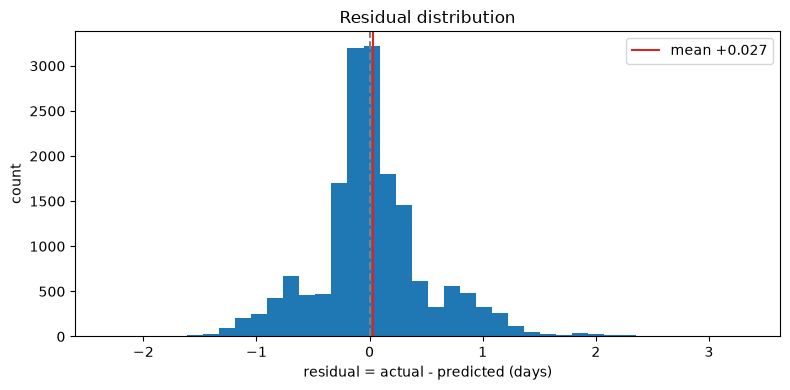

In [14]:
plt.figure(figsize=(8, 4))
plt.hist(resid, bins=40)
plt.axvline(0, c="grey", ls="--")
plt.axvline(resid.mean(), c="tab:red", ls="-", label=f"mean {resid.mean():+.3f}")
plt.xlabel("residual = actual - predicted (days)"); plt.ylabel("count"); plt.legend()
plt.title("Residual distribution"); plt.tight_layout();

## 2 · Residuals vs predicted

A flat cloud around 0 is ideal. A funnel (spread growing with the prediction) = heteroscedasticity; a tilt = bias that depends on the predicted value.

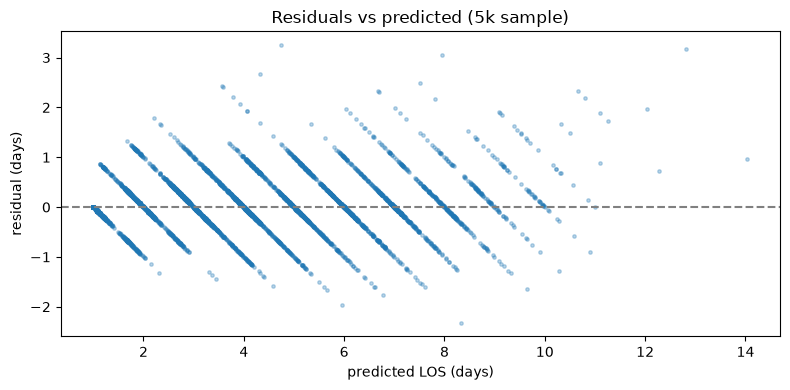

In [15]:
s = np.random.default_rng(0).choice(len(resid), size=min(5000, len(resid)), replace=False)
plt.figure(figsize=(8, 4))
plt.scatter(pred[s], resid[s], s=6, alpha=0.3)
plt.axhline(0, c="grey", ls="--")
plt.xlabel("predicted LOS (days)"); plt.ylabel("residual (days)")
plt.title("Residuals vs predicted (5k sample)"); plt.tight_layout();

## 3 · Residuals vs actual LOS — the ceiling check

The key plot for the known limitation. Sign convention: `residual = actual - predicted`, so **under-prediction gives a positive residual**. The LOS-17 cap forces the model to predict too low for long stays, so **mean residual should trend *positive* as actual LOS rises**. Watch the high-LOS end — that upward drift is the ceiling effect.

,mean,count
actual,,
1,-0.177274,3025
2,0.033140,2148
3,-0.004955,2752
4,-0.002677,2504
5,0.036392,2127
6,0.135516,1761
7,0.060321,1239
8,0.233772,748
9,0.363044,369


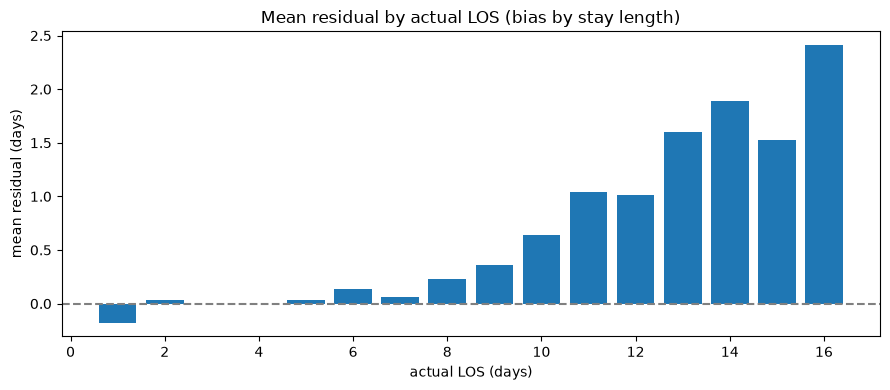

In [16]:
by_los = pd.DataFrame({"actual": y_test.to_numpy(), "resid": resid}).groupby("actual")["resid"].agg(["mean", "count"])
display(by_los)

plt.figure(figsize=(9, 4))
plt.bar(by_los.index, by_los["mean"])
plt.axhline(0, c="grey", ls="--")
plt.xlabel("actual LOS (days)"); plt.ylabel("mean residual (days)")
plt.title("Mean residual by actual LOS (bias by stay length)"); plt.tight_layout();

## 4 · Findings

Registered best model: **`log1p` variant (v2)** — test set n=16,953, MAE **0.355**, mean residual **+0.027**, std **0.517**.

- **Overall bias (mean residual):** essentially zero (**+0.027 days ≈ 40 min**). Aggregate predictions are unbiased. But this global number is *misleading* — it averages ~9,500 near-perfect short stays against a small tail of large errors (see ceiling effect below). The headline metric hides the model's real weakness.

- **`log1p` bias present?** Not visibly. We expected a slight *negative* bias from the `expm1` back-transform (Jensen's inequality). It's swamped by the ceiling effect (below), which pushes the tail's residuals positive, so net bias comes out mildly *positive*. The log1p relative-error objective keeps short stays tight; it just can't rescue the capped tail.

- **Ceiling effect at high LOS?** **Yes — clear and monotonic.** Mean residual is ~0 for LOS 1–5, then climbs steadily with stay length: +0.14 (LOS 6) → +0.36 (LOS 9) → +0.64 (LOS 10) → +1.04 (LOS 11) → +1.60 (LOS 13) → **+2.41 (LOS 16)**. Positive = systematic **under-prediction** of long stays, worsening toward the LOS-17 cap. Invisible in the global bias only because these stays are rare (LOS ≥ 11 is ~110 of 16,953 rows, <0.7%). Mirror effect at the floor: LOS=1 shows −0.18 (mild over-prediction) from the clip at 1.

- **Heteroscedasticity / pattern vs predicted?** **Yes.** Residual std grows with the prediction: 0.36 (pred ≤ 2) → 0.56 (4–6) → 0.71 (8–10) → **1.16 (> 10)**. The error funnel widens exactly where stays get long — the same failure mode as the ceiling, seen from the prediction side.

- **Clinical framing (Phase 5 seed):** the model is **most accurate on routine short stays and least accurate on long, high-resource patients** — the opposite of where reliability matters most for capacity planning and discharge risk. The largest errors concentrate in the long-stay tail. Any downstream use should flag long-stay predictions as systematically conservative (biased low) and treat them with wider uncertainty. This under-prediction of the tail is the headline limitation to carry into the explainability phase.

## 5 · Limitations & implications for use

The headline weakness is the **under-prediction of long stays** (§3–§4). Whether that is a problem depends entirely on the use case — the same error is harmless in one workflow and dangerous in another.

**Fine for:**
- **Aggregate / capacity planning** (e.g. total bed-days across a ward). The tail is <0.7% of patients and the global bias is ~0 (+0.027 days), so summed forecasts are effectively unbiased.
- **Routine typical stays** (LOS 1–8, 95%+ of patients), where error is ~⅓ day.

**Risky for:**
- **Identifying long-stay / high-risk patients** — often the whole point of an LOS model. The model is systematically conservative *exactly where it matters most*: it under-predicts by 1–2.4 days for the longest stays, so it will **under-flag** the cases the tool is meant to catch.
- **Any downstream threshold** (e.g. "alert if predicted LOS > 10"). Long-stayers get pulled below the threshold → false negatives concentrate in the highest-severity cases. The bias is directional, in the costly direction.

**Why it happens (two causes):**
1. **Data artifact.** The Microsoft synthetic dataset caps LOS at 17 and has almost no long-stay examples to learn from (12 rows at LOS 13, 2 at LOS 16). The model literally cannot predict beyond the range it saw. Real hospital data has a longer, fatter tail — the true version of this problem would be *worse*, though real long-stay examples would also be available to learn from.
2. **Fundamental to mean-error regression on a rare heavy tail.** The objective minimizes average error, which is dominated by short stays. This is a limitation to manage, not a bug to tune away.

**Levers for later (not fixed here):**
- **Report uncertainty**, not just a point estimate — wider intervals on long-stay predictions so users don't trust the number blindly.
- **Reframe as classification** for the actual decision — e.g. `P(LOS > 7 days)` is often more robust and more useful than a point estimate, and sidesteps the ceiling.
- **Cost-sensitive / quantile objective** — if under-prediction is the expensive error, predict an upper quantile (e.g. 75th percentile) rather than the mean.

**Carry-forward:** this under-prediction of the tail is the model's known limitation. It belongs in a model card, and it's the natural hook for Phase 5 explainability — SHAP on the long-stay errors would show *why* the model can't reach them.